AMB2275_TANUJA SL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
Salary_data=pd.read_csv("Salary_Data.csv")
print(Salary_data.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


In [ ]:
#slice the dataset as descriptive (independent)and
#target vaiable (dependent)
X=Salary_data.iloc[:,0:1].values
y=Salary_data.iloc[:,-1].values
print(X)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [ ]:
#preprocessing(optional)
# splitting the dataset into training and testing set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=1/3,random_state=0)
print(Salary_data.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(30, 2)
(20, 1)
(10, 1)
(20,)
(10,)


linear regression without in built function

In [ ]:
#calculate the mean values of input and output
x_mean=np.mean(X_train)
y_mean=np.mean(y_train)
print(x_mean)
print(y_mean)

4.7299999999999995
71022.5


In [ ]:
#calculate intercept and coefficient
n=len(X_train)
num,den=0,0
for i in range(n):
  num+=(X_train[i]-x_mean)*(y_train[i]-y_mean)
  den+=(X_train[i]-x_mean)**2
b1=num/den
b0=y_mean-(b1*x_mean)
print("b0:",b0)

b0: [26816.19224403]


In [ ]:
#predicting results on test dataset
y_pred_code=b0+b1*X_test
print(y_pred_code)

[[ 40835.10590871]
 [123079.39940819]
 [ 65134.55626083]
 [ 63265.36777221]
 [115602.64545369]
 [108125.8914992 ]
 [116537.23969801]
 [ 64199.96201652]
 [ 76349.68719258]
 [100649.1375447 ]]


In [ ]:
print(y_test)

[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]


In [ ]:
n1=len((y_test))
mse=0
for i in range(n1):
  mse+=(y_pred_code[i]-y_test[i])**2
mse=mse/n1
print(mse)
#root mean square error
rsme=np.sqrt(mse)
print(rsme)


[21026037.3295113]
[4585.41572047]


In [ ]:
#create an object of algorithm/model
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
#train the model
reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
#predict the model on testing dataset
y_pred=reg.predict(X_test)
print(y_pred)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [ ]:
#calculate the intercept and the coefficient
print("intercept",reg.intercept_)
print("coefficient",reg.coef_)

intercept 26816.192244031183
coefficient [9345.94244312]


In [ ]:
#evaluation metrics
from sklearn import metrics
print("mean absolute error")
print(metrics.mean_absolute_error(y_test,y_pred))
print("mean squared error")
print(metrics.mean_squared_error(y_test,y_pred))
print("rooted mean square error")
print(np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

mean absolute error
3426.4269374307078
mean squared error
21026037.329511296
rooted mean square error
4585.4157204675885


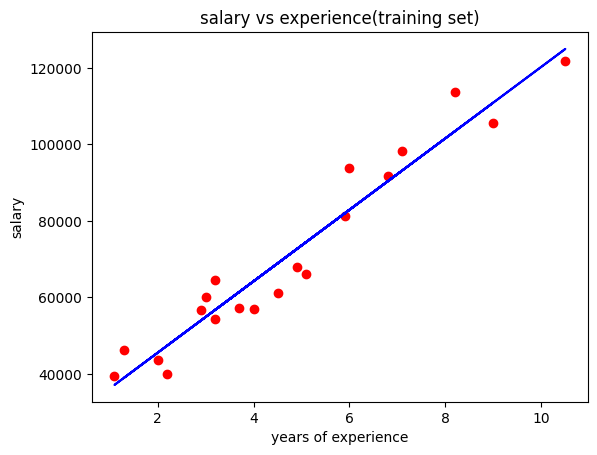

In [ ]:
#visualisation
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("salary vs experience(training set)")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()

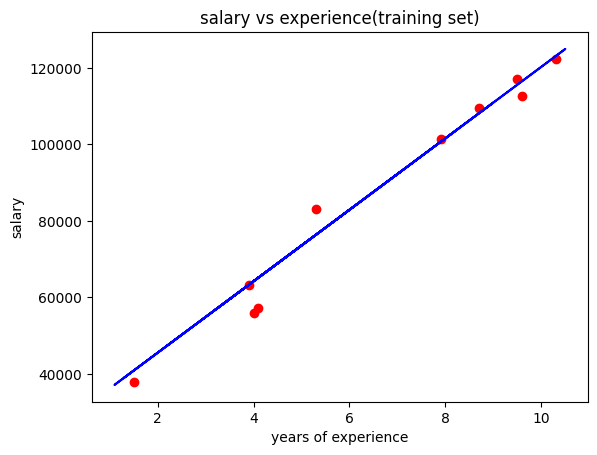

In [ ]:
plt.scatter(X_test,y_test,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("salary vs experience(training set)")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()

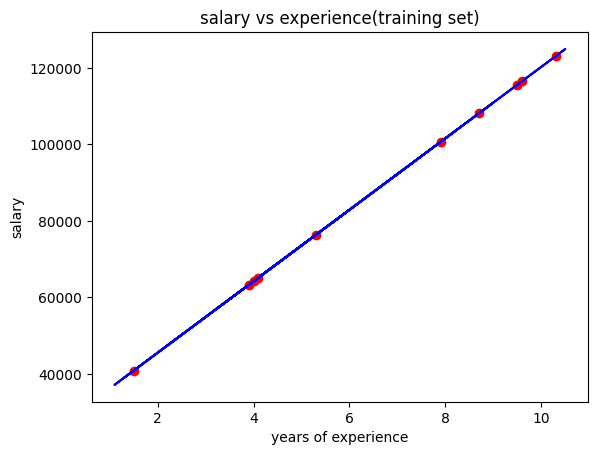

In [ ]:
import matplotlib.pyplot as plt
#visualisation

plt.scatter(X_test,y_pred,color='red')
plt.plot(X_train,reg.predict(X_train),color='blue')
plt.title("salary vs experience(training set)")
plt.xlabel("years of experience")
plt.ylabel("salary")
plt.show()